# Notebook to re-create the Figures and Table from Section 3. Results

To create the figures in this notebook, the trained LIF-DL needs to have been deployed to create a forecast, and evaluations need to have been performed.

See scripts/ forecast.py and evaluate.py. Remember to save the intermediate results of the evaluation by setting the --save_intermediate flag in the command line.

In [10]:
# IMPORTS
import importlib
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import src.utils.plotting as plotting

from src.utils import (
    plot_fic_temporal_evolution,
    plot_local_morans_i,
    plot_spatial_model_error_maps,
    plot_spatial_timing_maps,
    plot_variable_importance_grouped,
    plot_variable_importance_monthly_heatmap,
)


def reload_plotting_utils():
    """Reload plotting utilities and refresh notebook-level function bindings."""
    global plot_fic_temporal_evolution
    global plot_local_morans_i
    global plot_spatial_model_error_maps
    global plot_spatial_timing_maps
    global plot_variable_importance_grouped
    global plot_variable_importance_monthly_heatmap

    importlib.reload(plotting)

    plot_fic_temporal_evolution = plotting.plot_fic_temporal_evolution
    plot_local_morans_i = plotting.plot_local_morans_i
    plot_spatial_model_error_maps = plotting.plot_spatial_model_error_maps
    plot_spatial_timing_maps = plotting.plot_spatial_timing_maps
    plot_variable_importance_grouped = plotting.plot_variable_importance_grouped
    plot_variable_importance_monthly_heatmap = plotting.plot_variable_importance_monthly_heatmap

    print("Reloaded plotting utilities from src.utils.plotting")

In [11]:
## SETUP - set constants for the notebook

# Define model path
model_name = "LIF_DL_Best"
eval_dir = Path(f"../results/{model_name}/evaluations")

# Obs order
obs_order = ["IMS", "CIS"]
# Model order
model_order = ["LIF_DL", "FLake"]
# Lake order
lake_order = [
    "Great_Bear_Lake",
    "Great_Slave_Lake",
    "Lake_Athabasca",
    "Reindeer_Lake",
    "Lake_Winnipeg"
]

# Set the figure path if you want to save the figures
fig_dir = Path(f"../results/{model_name}/figures/")
# fig_path = None
if fig_dir and not fig_dir.exists():
    os.mkdir(fig_dir)

# Check if the evaluation directory exists and has the desired files
if not eval_dir.exists():
    raise FileNotFoundError(f"Evaluation directory {eval_dir} does not exist.")

# check for fic, overall, phenology and spatial csvs
required_files = [
    "fic.csv",
    "overall.csv",
    "phenology.csv",
    "spatial.csv"
]
for file in required_files:
    if not (eval_dir / file).exists():
        raise FileNotFoundError(f"Required file {file} not found in {eval_dir}.")
    
# Check for intermediate files
intermediate_dir = eval_dir / "intermediate"
if not intermediate_dir.exists():
    raise FileNotFoundError(f"Intermediate directory {intermediate_dir} does not exist.")


## 3.1 Variable Importance

In [ ]:
# Load variable importance results from the new monthly normalized wide format
monthly_vi_df = pd.read_csv(eval_dir / "variable_importances_normalized.csv")

print(f"Loaded monthly variable importance from: {eval_dir / 'variable_importances_normalized.csv'}")
print(f"Shape: {monthly_vi_df.shape}")
print()
print("Monthly Variable Importance Results (first 5 rows):")
print("="*100)
print(monthly_vi_df.head().round(4).to_string(index=False))
print("="*100)

# Extract seasonal aggregates (Breakup and Freezeup columns) for legacy compatibility
# This creates a dataframe compatible with the old format for the grouped bar chart
vi_df = pd.DataFrame({
    'Variable': monthly_vi_df['Variable'],
    'Breakup': monthly_vi_df['Breakup'],
    'Freezeup': monthly_vi_df['Freezeup']
})

print("\nExtracted Seasonal Aggregates for Visualization:")
print("="*70)
print(vi_df.round(4).to_string(index=False))
print("="*70)

Loaded monthly variable importance from: ../results/LIF_DL_Best/evaluations/variable_importances_monthly_normalized_wide.csv
Shape: (9, 15)

Monthly Variable Importance Results (first 5 rows):
                             Variable    Jan    Feb    Mar    Apr    May    Jun    Jul    Aug    Sep    Oct    Nov    Dec  Breakup  Freezeup
                       temperature_2m 0.1435 0.1547 0.1522 0.1604 0.1612 0.1518 0.1377 0.1497 0.1620 0.1642 0.1339 0.1095   0.1554    0.1361
                       wind_speed_10m 0.0377 0.0300 0.0302 0.0303 0.0309 0.0326 0.0360 0.0361 0.0414 0.0363 0.0367 0.0360   0.0319    0.0366
surface_solar_radiation_downwards_sum 0.1833 0.0918 0.0874 0.0881 0.0975 0.0925 0.1011 0.2084 0.2101 0.1621 0.1765 0.1960   0.0948    0.1767
              total_precipitation_sum 0.0391 0.0652 0.0637 0.0574 0.0420 0.0365 0.0339 0.0335 0.0358 0.0447 0.0340 0.0280   0.0403    0.0350
                    relative_humidity 0.0464 0.0623 0.0650 0.0650 0.0619 0.0588 0.0557 0.0549 0.0496 0

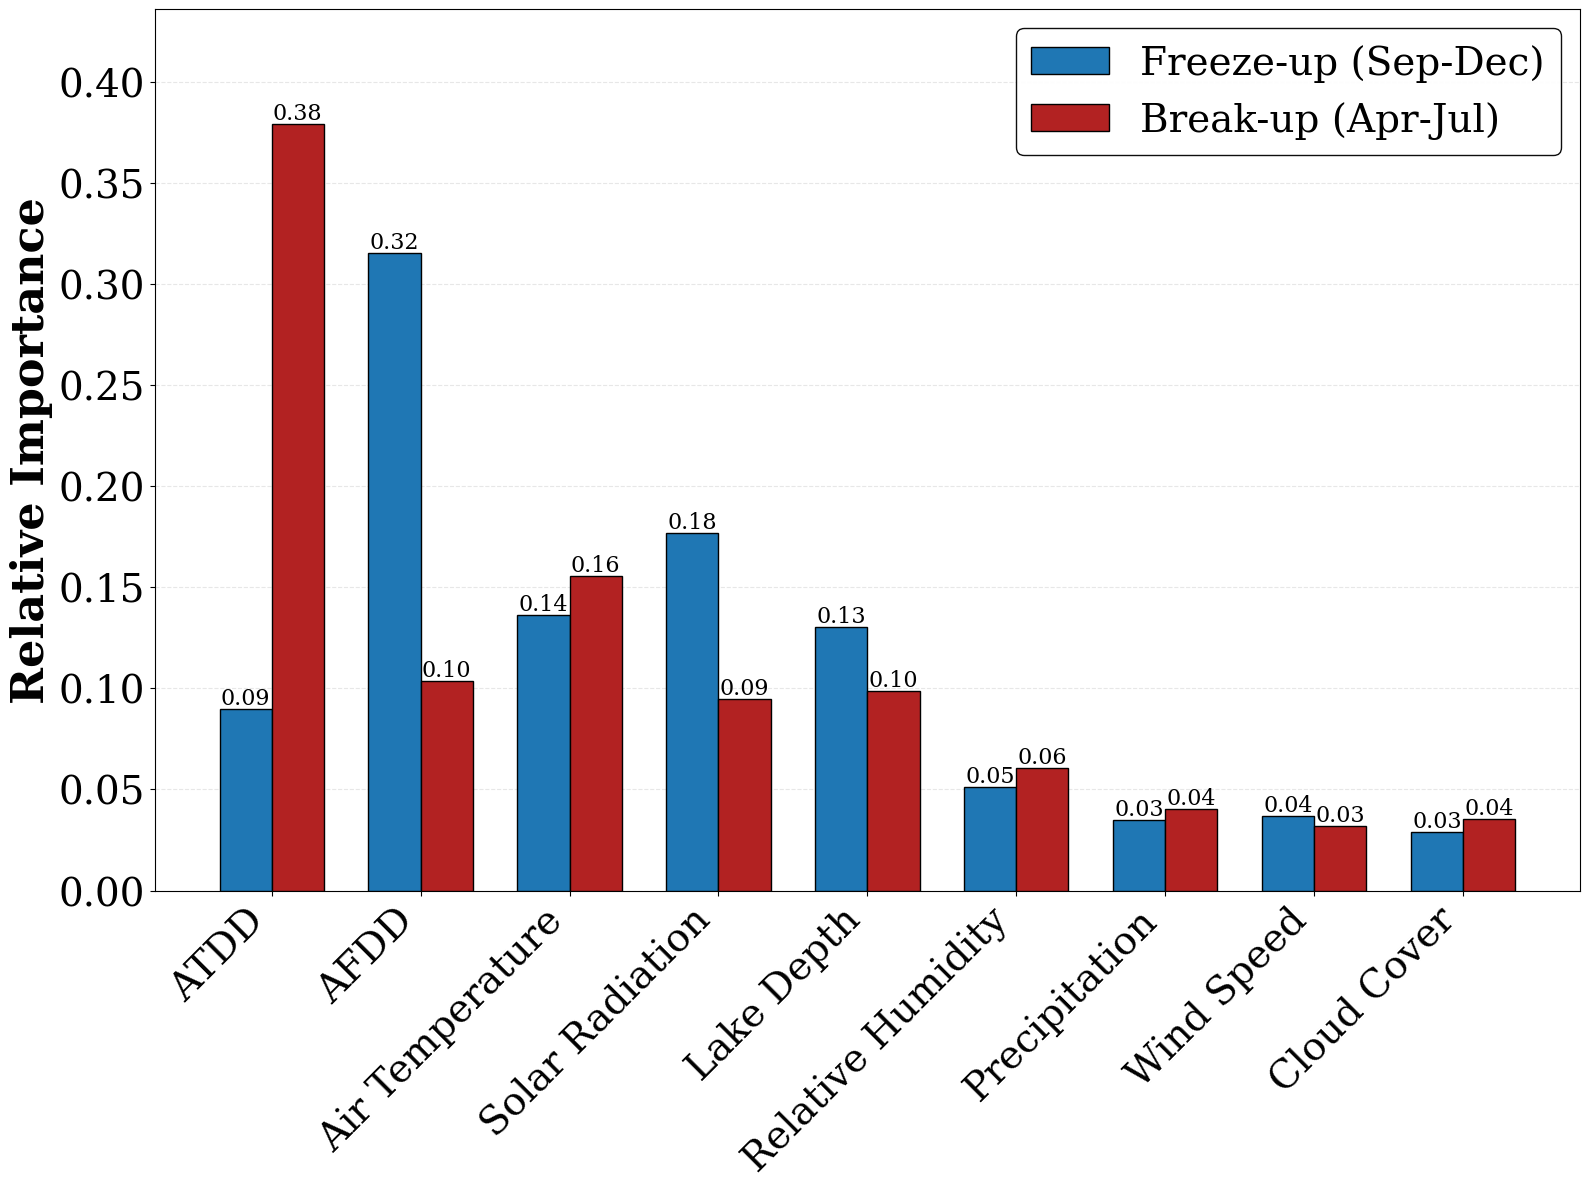

In [29]:
# Sort variables by average importance across both freezeup and breakup
sorted_vars = vi_df.set_index('Variable')[['Freezeup', 'Breakup']].mean(axis=1)
sorted_vars = sorted_vars.sort_values(ascending=False).index.tolist()
custom_variable_order = sorted_vars

# Define custom labels for cleaner display names
custom_variable_labels = {
    'temperature_2m': 'Air Temperature',
    'wind_speed_10m': 'Wind Speed',
    'surface_solar_radiation_downwards_sum': 'Solar Radiation',
    'total_precipitation_sum': 'Precipitation',
    'relative_humidity': 'Relative Humidity',
    'total_cloud_cover': 'Cloud Cover',
    'accumulated_freezing_dd': 'AFDD',
    'accumulated_thawing_dd': 'ATDD',
    'lake_depth': 'Lake Depth'
}

# Create the grouped bar chart
fig = plot_variable_importance_grouped(
    vi_df, 
    variable_order=custom_variable_order,
    variable_labels=custom_variable_labels,
    save_path=fig_dir/"variable_importance.png"
)
plt.show()

Saved heatmap to: ../results/LIF_DL_Best/figures/variable_importance_monthly_heatmap.png


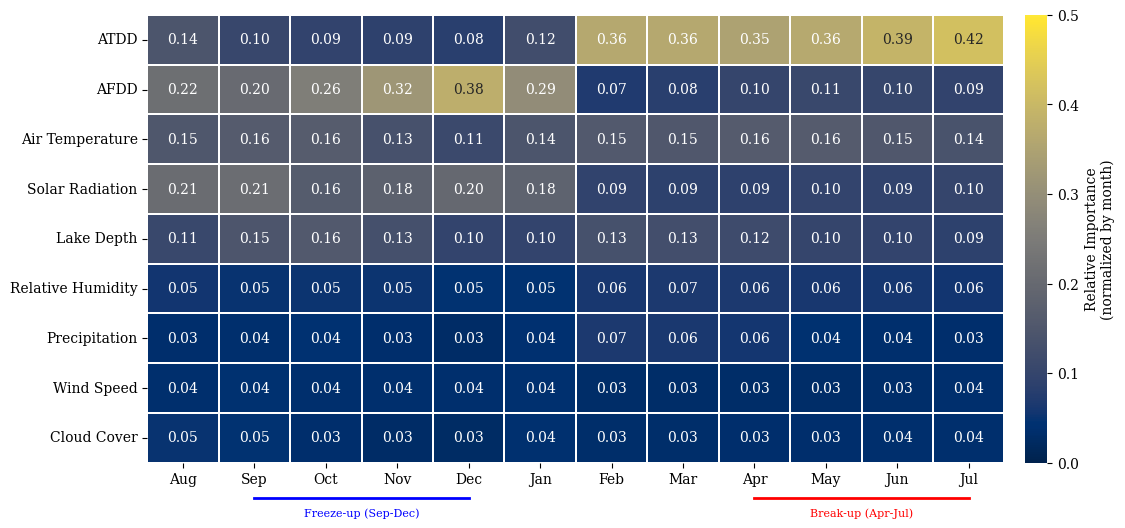

In [ ]:
# Monthly variable importance heatmap (variables × months + seasonal aggregates)
import importlib
import src.utils.plotting
importlib.reload(src.utils.plotting)
from src.utils.plotting import plot_variable_importance_monthly_heatmap

# Resolve evaluation directory if this cell is run independently
if 'eval_dir' not in globals():
    model_name = "LIF_DL_Best"
    eval_dir = Path(f"../results/{model_name}/evaluations")

# Load the monthly normalized wide format (already loaded in first VI cell)
if 'monthly_vi_df' not in globals():
    monthly_vi_df = pd.read_csv(eval_dir / "variable_importances_normalized.csv")
    print(f"Loaded monthly VI from: {eval_dir / 'variable_importances_normalized.csv'}")

fig = plot_variable_importance_monthly_heatmap(
    vi_df=monthly_vi_df,
    variable_order=custom_variable_order if 'custom_variable_order' in globals() else None,
    variable_labels=custom_variable_labels if 'custom_variable_labels' in globals() else None,
    save_path=fig_dir / "variable_importance_monthly_heatmap.png" if 'fig_dir' in globals() else None
)

if 'fig_dir' in globals():
    print(f"Saved heatmap to: {fig_dir / 'variable_importance_monthly_heatmap.png'}")

plt.show()

## 3.2 Full Forecast Evaluation

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

: 

: 

In [ ]:
# Load overall evaluation CSV
overall_df = pd.read_csv(eval_dir / "overall.csv")

# Compute "Overall" results (average across lakes) per Obs and Model without attempting to average the Lake column
# Keep only the Obs/Model and numeric columns for aggregation
cols_for_agg = [c for c in overall_df.columns if c not in ['Lake']]
average_df = overall_df[cols_for_agg].groupby(['Obs', 'Model'], as_index=False).mean()
average_df['Lake'] = 'Average'

# Reorder columns to match original: Lake, Obs, Model, then the rest
rest_cols = [c for c in overall_df.columns if c not in ['Lake', 'Obs', 'Model']]
average_df = average_df[['Lake', 'Obs', 'Model'] + rest_cols]

# Append the overall rows to the phenology dataframe
overall_df = pd.concat([overall_df, average_df], ignore_index=True)

print(f"Loaded overall evaluation from: {eval_dir / 'overall.csv'}")
print(f"Shape: {overall_df.shape}")
print()

# Convert Lake names to match the order (fix capitalization)
overall_df['Lake'] = overall_df['Lake'].str.replace('_', ' ').str.title().str.replace(' ', '_')
overall_df['Model'] = overall_df['Model'].str.upper().replace('LIF-DL', 'LIF_DL').replace('FLAKE', 'FLake')

# Create categorical ordering for sorting
overall_df['Lake'] = pd.Categorical(overall_df['Lake'], categories=lake_order+["Average"], ordered=True)
overall_df['Obs'] = pd.Categorical(overall_df['Obs'], categories=obs_order, ordered=True)
overall_df['Model'] = pd.Categorical(overall_df['Model'], categories=model_order, ordered=True)

# Sort by Lake, Obs, Model
overall_df = overall_df.sort_values(['Lake', 'Obs', 'Model'])

# Set multi-index
display_table = overall_df.set_index(['Lake', 'Obs', 'Model'])

# Display the full table
print("Full Forecast Evaluation - Overall Metrics")
print("="*120)

# Set the pandas float format for precision
pd.options.display.float_format = '{:.2f}'.format
display_table

Loaded overall evaluation from: ../results/LIF_DL_Best/evaluations/overall.csv
Shape: (12, 14)

Full Forecast Evaluation - Overall Metrics


All_Accuracy  All_F1  All_IoU  Breakup_Accuracy  \
Lake             Obs Model                                                     
Great_Bear_Lake  IMS LIF_DL          0.97    0.98     0.96              0.97   
                     FLake           0.92    0.94     0.89              0.91   
Great_Slave_Lake IMS LIF_DL          0.97    0.97     0.94              0.96   
                     FLake           0.94    0.95     0.91              0.95   
Lake_Athabasca   IMS LIF_DL          0.96    0.97     0.93              0.96   
                     FLake           0.93    0.94     0.88              0.95   
Reindeer_Lake    IMS LIF_DL          0.96    0.97     0.94              0.96   
                     FLake           0.95    0.96     0.92              0.95   
Lake_Winnipeg    IMS LIF_DL          0.95    0.95     0.91              0.96   
                     FLake           0.96    0.96     0.92              0.95   
Average          IMS LIF_DL          0.96    0.97     0.94              0.96   
                     FLake           0.94    0.95     0.90              0.94   

                             Breakup_F1  Breakup_IoU  Freezeup_Accuracy  \
Lake             Obs Model                                                
Great_Bear_Lake  IMS LIF_DL        0.98         0.96               0.95   
                     FLake         0.94         0.89               0.86   
Great_Slave_Lake IMS LIF_DL        0.97         0.94               0.94   
                     FLake         0.96         0.92               0.88   
Lake_Athabasca   IMS LIF_DL        0.96         0.92               0.93   
                     FLake         0.95         0.90               0.85   
Reindeer_Lake    IMS LIF_DL        0.97         0.94               0.93   
                     FLake         0.96         0.92               0.91   
Lake_Winnipeg    IMS LIF_DL        0.95         0.90               0.91   
                     FLake         0.95         0.90               0.92   
Average          IMS LIF_DL        0.96         0.93               0.93   
                     FLake         0.95         0.91               0.88   

                             Freezeup_F1  Freezeup_IoU  n_timesteps  n_pixels  
Lake             Obs Model                                                     
Great_Bear_Lake  IMS LIF_DL         0.93          0.87      1461.00   1908.00  
                     FLake          0.83          0.71      1461.00   1908.00  
Great_Slave_Lake IMS LIF_DL         0.90          0.83      1461.00   1243.00  
                     FLake          0.85          0.74      1461.00   1243.00  
Lake_Athabasca   IMS LIF_DL         0.90          0.82      1461.00    536.00  
                     FLake          0.82          0.69      1461.00    536.00  
Reindeer_Lake    IMS LIF_DL         0.90          0.82      1461.00    473.00  
                     FLake          0.89          0.80      1461.00    473.00  
Lake_Winnipeg    IMS LIF_DL         0.86          0.75      1461.00   1680.00  
                     FLake          0.90          0.82      1461.00   1680.00  
Average          IMS LIF_DL         0.90          0.82      1461.00   1168.00  
                     FLake          0.86          0.75      1461.00   1168.00

: 

: 

## 3.3 Spatial Accuracy

In [20]:
reload_plotting_utils()

# Load spatial map data from intermediate files
import xarray as xr

# Path to intermediate spatial maps
spatial_dir = eval_dir / "intermediate" / "spatial_maps"

# Load all spatial maps for each lake and source
spatial_data = {}
sources = ["ims", "lif_dl", "flake"]

for lake in lake_order:
    lake_key = lake.lower().replace(' ', '_')
    spatial_data[lake] = {}

    for source in sources:
        file_path = spatial_dir / f"{lake_key}_{source}.nc"
        if file_path.exists():
            ds = xr.open_dataset(file_path)
            spatial_data[lake][source] = ds
            print(f"Loaded: {file_path.name}")
        else:
            print(f"Missing: {file_path.name}")

print(f"\nLoaded spatial data for {len(spatial_data)} lakes")
print(f"Sources per lake: {sources}")

Reloaded plotting utilities from src.utils.plotting
Loaded: great_bear_lake_ims.nc
Loaded: great_bear_lake_lif_dl.nc
Loaded: great_bear_lake_flake.nc
Loaded: great_slave_lake_ims.nc
Loaded: great_slave_lake_lif_dl.nc
Loaded: great_slave_lake_flake.nc
Loaded: lake_athabasca_ims.nc
Loaded: lake_athabasca_lif_dl.nc
Loaded: lake_athabasca_flake.nc
Loaded: reindeer_lake_ims.nc
Loaded: reindeer_lake_lif_dl.nc
Loaded: reindeer_lake_flake.nc
Loaded: lake_winnipeg_ims.nc
Loaded: lake_winnipeg_lif_dl.nc
Loaded: lake_winnipeg_flake.nc

Loaded spatial data for 5 lakes
Sources per lake: ['ims', 'lif_dl', 'flake']


In [21]:
# Load the spatial evaluation metrics for SSIM values
spatial_df = pd.read_csv(eval_dir / "spatial.csv")

# Fix lake and model names to match
spatial_df['Lake'] = spatial_df['Lake'].str.replace('_', ' ').str.title().str.replace(' ', '_')
spatial_df['Model'] = spatial_df['Model'].str.upper().replace('LIF-DL', 'LIF-DL')

print(f"Loaded spatial metrics: {spatial_df.shape}")
spatial_df.head()

Loaded spatial metrics: (10, 9)


,Lake,Obs,Model,FUS_SSIM,FUS_Kendall_Tau_B,FUS_LMI_IoU,BUS_SSIM,BUS_Kendall_Tau_B,BUS_LMI_IoU
0,Great_Bear_Lake,IMS,FLAKE,0.130056,0.582740,0.520417,-0.009577,0.285225,0.168251
1,Great_Bear_Lake,IMS,LIF-DL,0.241003,0.561572,0.431049,0.152796,0.562224,0.515994
2,Great_Slave_Lake,IMS,FLAKE,0.169148,0.601231,0.502377,-0.035928,0.254428,0.191379
3,Great_Slave_Lake,IMS,LIF-DL,0.378518,0.687532,0.524333,0.253744,0.631988,0.539655
4,Lake_Athabasca,IMS,FLAKE,0.061925,0.458245,0.372159,-0.017936,0.308871,0.097872


### 3.3.1 Break-up Start

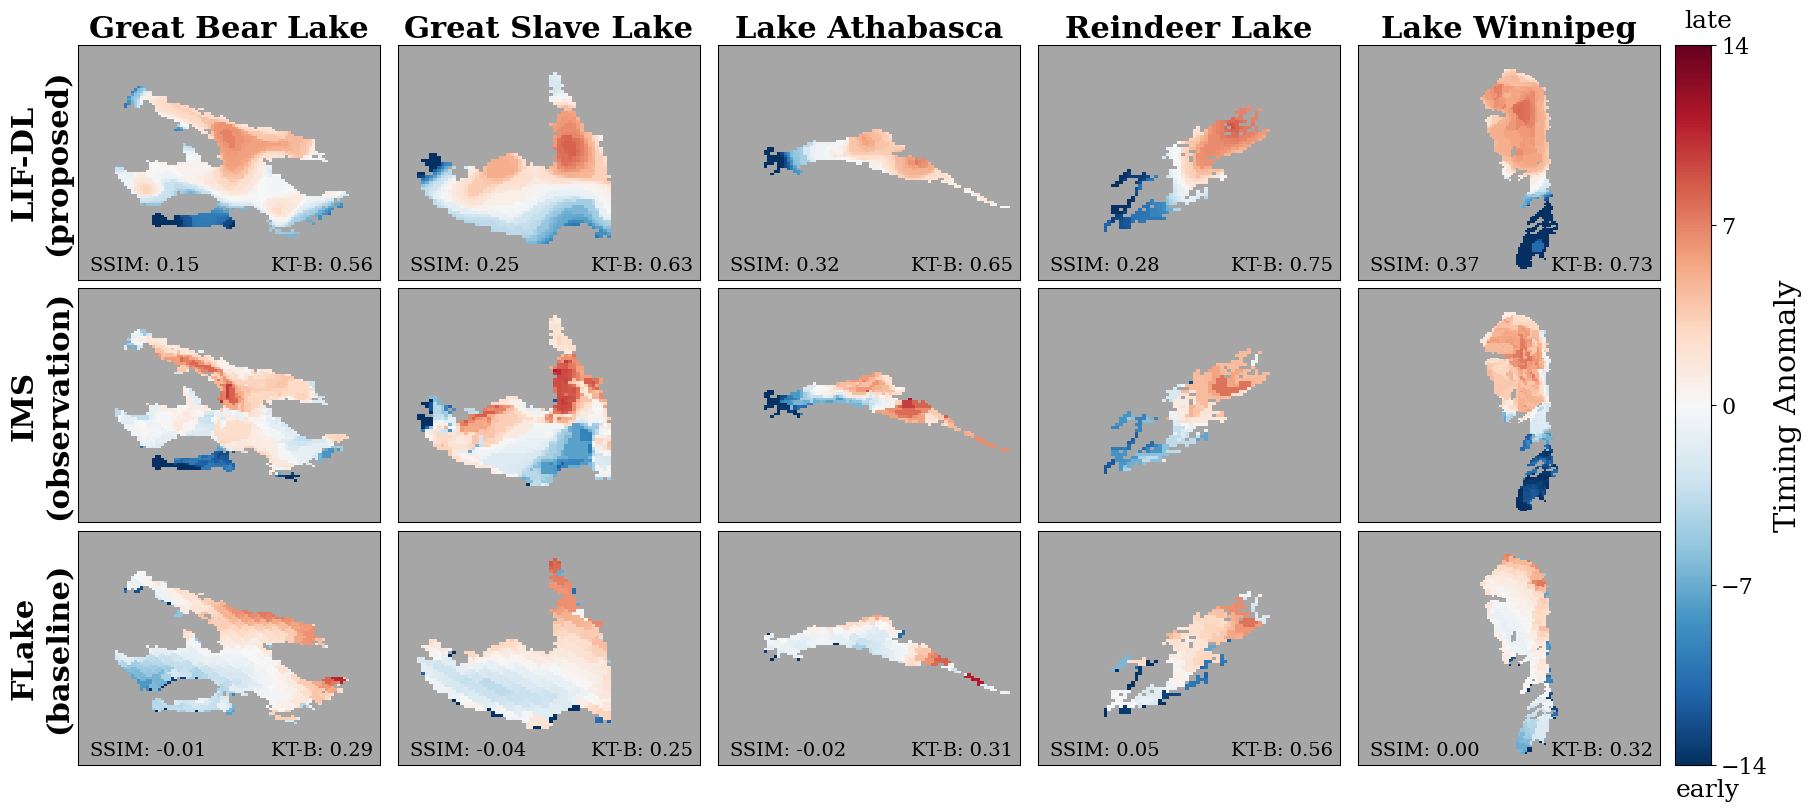

In [22]:
# Create Break-up Start (BUS) spatial timing anomaly map
fig_bus = plot_spatial_timing_maps(spatial_data, season='BUS', spatial_df=spatial_df, lake_order=lake_order, save_path=fig_dir/"BUS_timing.png")
plt.show()

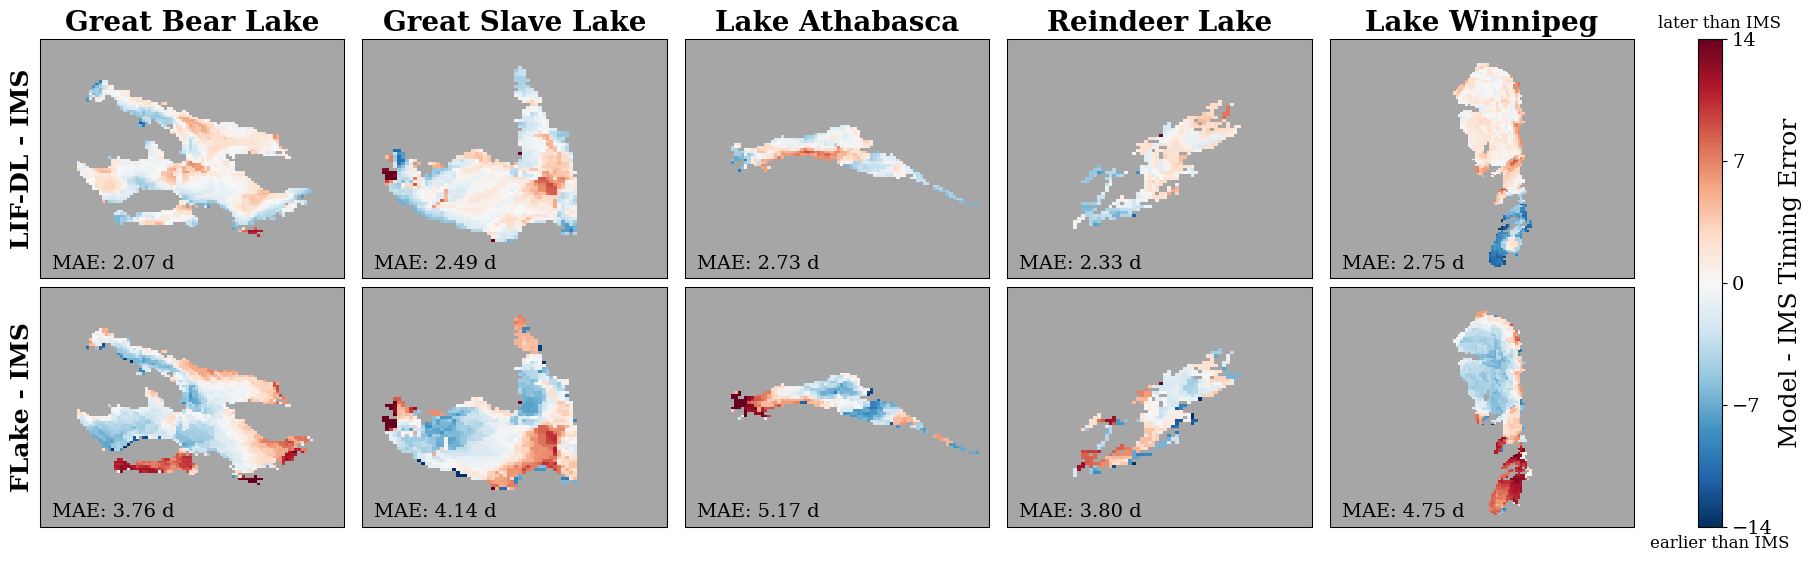

In [23]:
# Create model-minus-IMS error maps for Break-up Start (BUS)
fig_bus_err = plot_spatial_model_error_maps(
    spatial_data,
    season='BUS',
    lake_order=lake_order,
    save_path=fig_dir/"BUS_model_minus_IMS_timing_error.png"
)
plt.show()

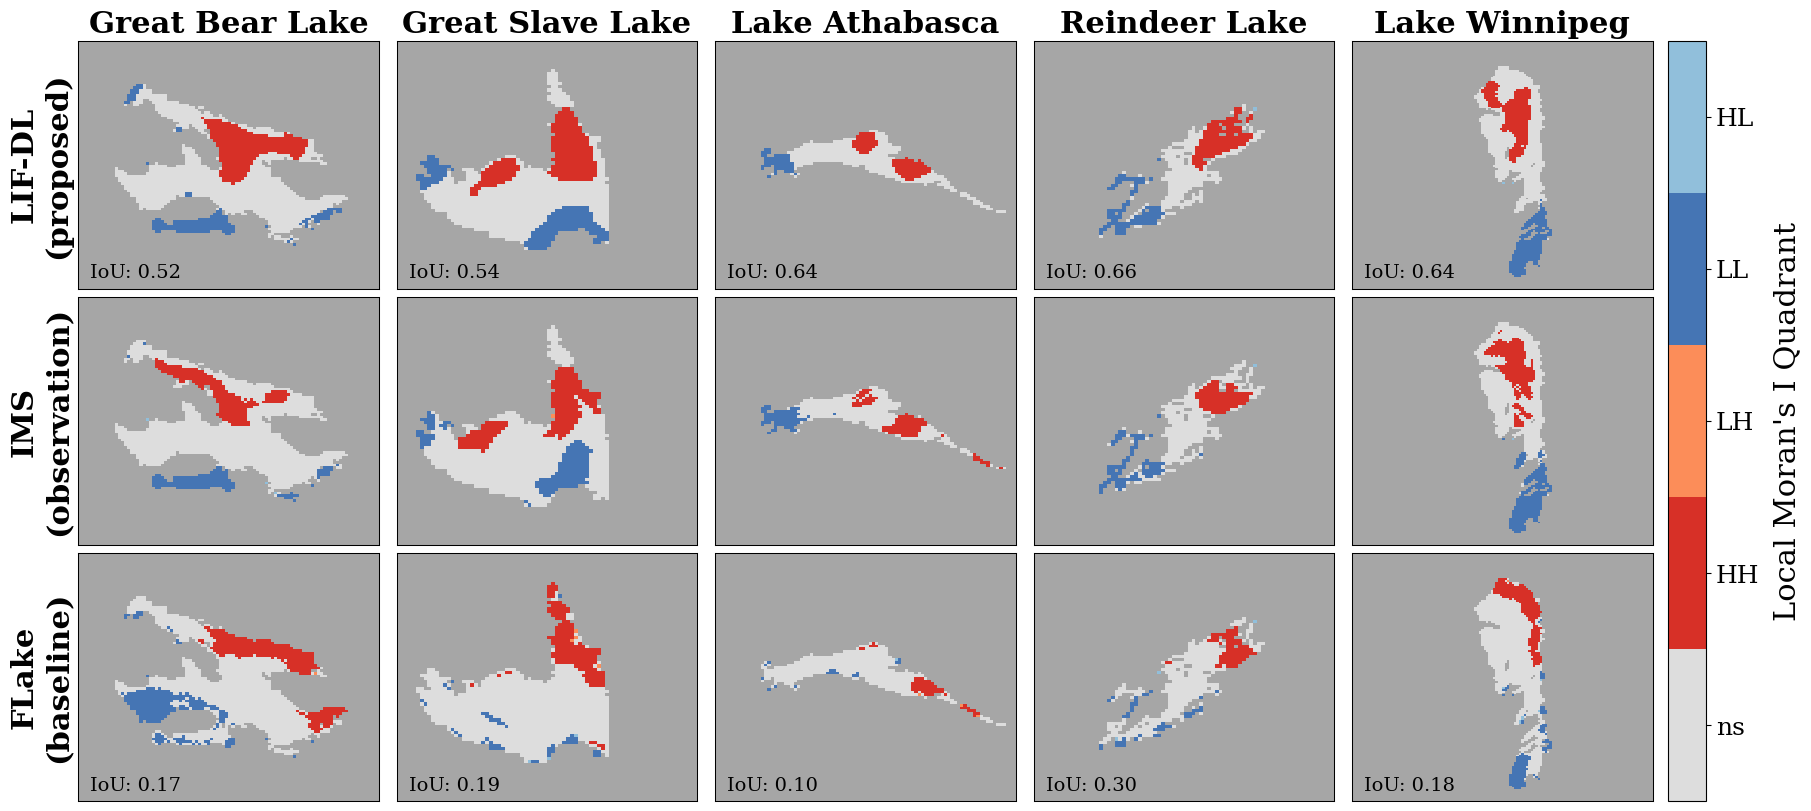

In [24]:
# Create Break-up Start (BUS) Local Moran's I cluster map
fig_bus_lmi = plot_local_morans_i(spatial_data, season='BUS', spatial_df=spatial_df, lake_order=lake_order, save_path=fig_dir/"BUS_lmi.png")
plt.show()

### 3.3.2 Freeze-up Start

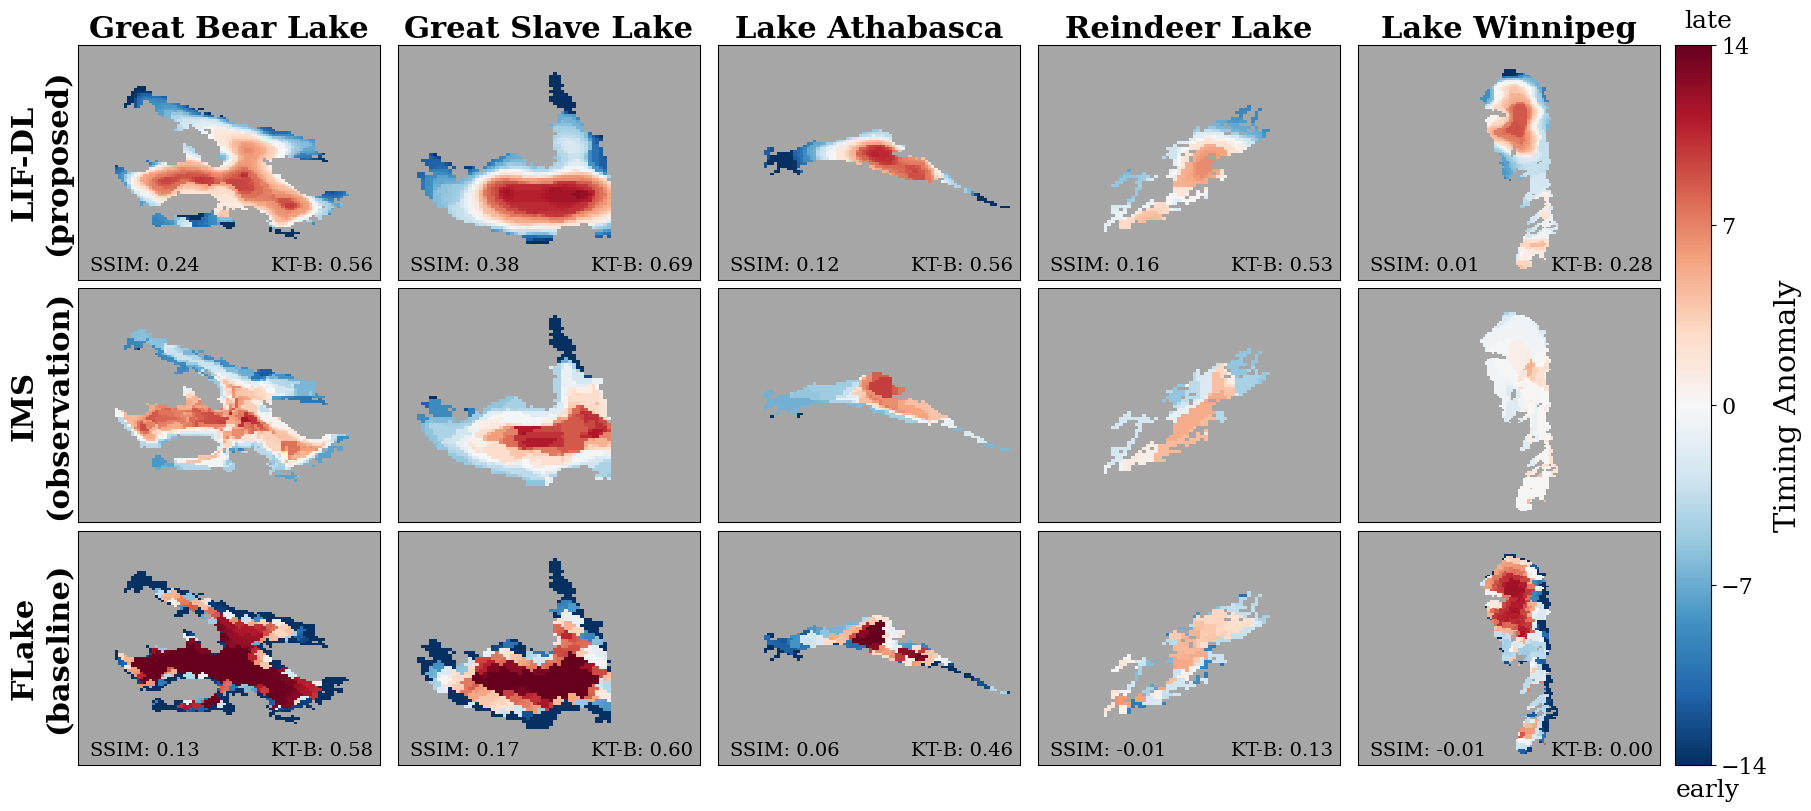

In [25]:
# Create Freeze-up Start (FUS) spatial timing anomaly map
fig_fus = plot_spatial_timing_maps(spatial_data, season='FUS', spatial_df=spatial_df, lake_order=lake_order, save_path=fig_dir/"FUS_timing.png")
plt.show()

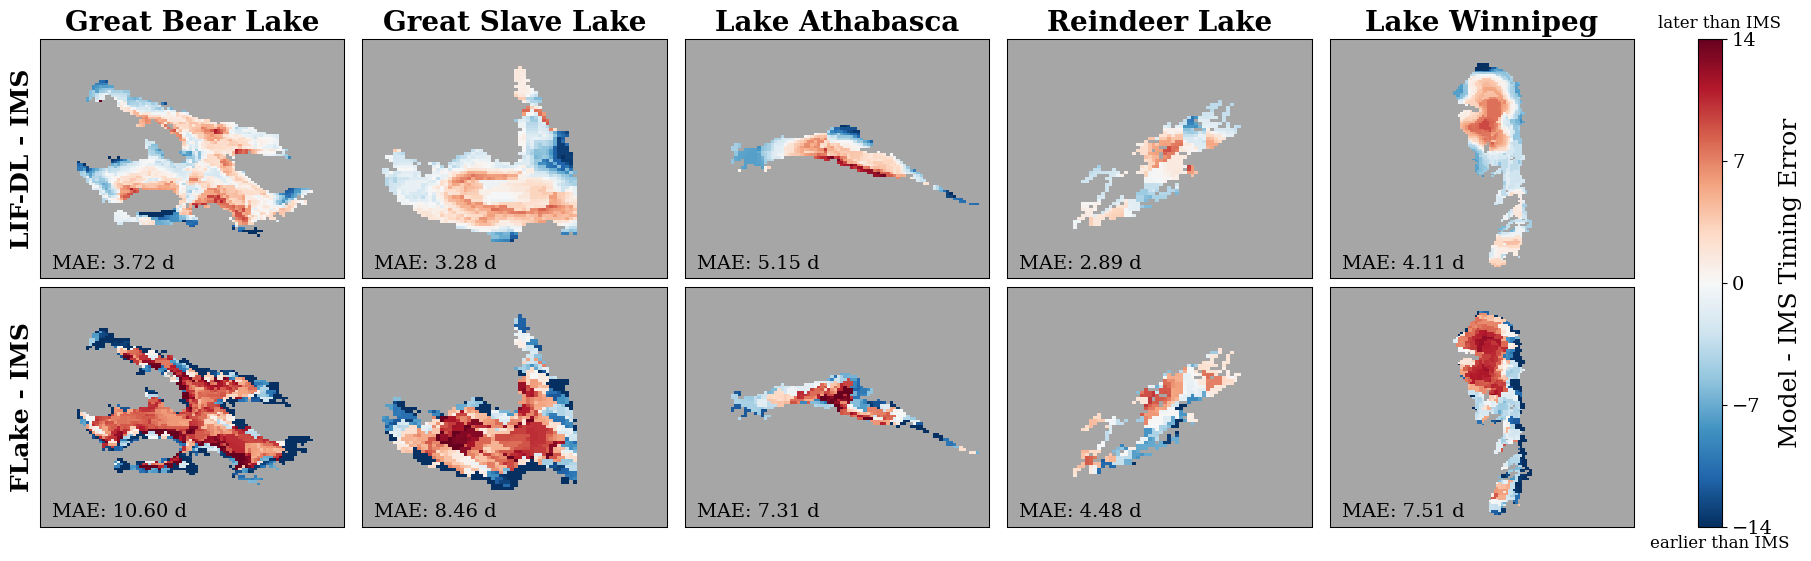

In [26]:
# Create model-minus-IMS error maps for Freeze-up Start (FUS)
fig_fus_err = plot_spatial_model_error_maps(
    spatial_data,
    season='FUS',
    lake_order=lake_order,
    save_path=fig_dir/"FUS_model_minus_IMS_timing_error.png"
)
plt.show()

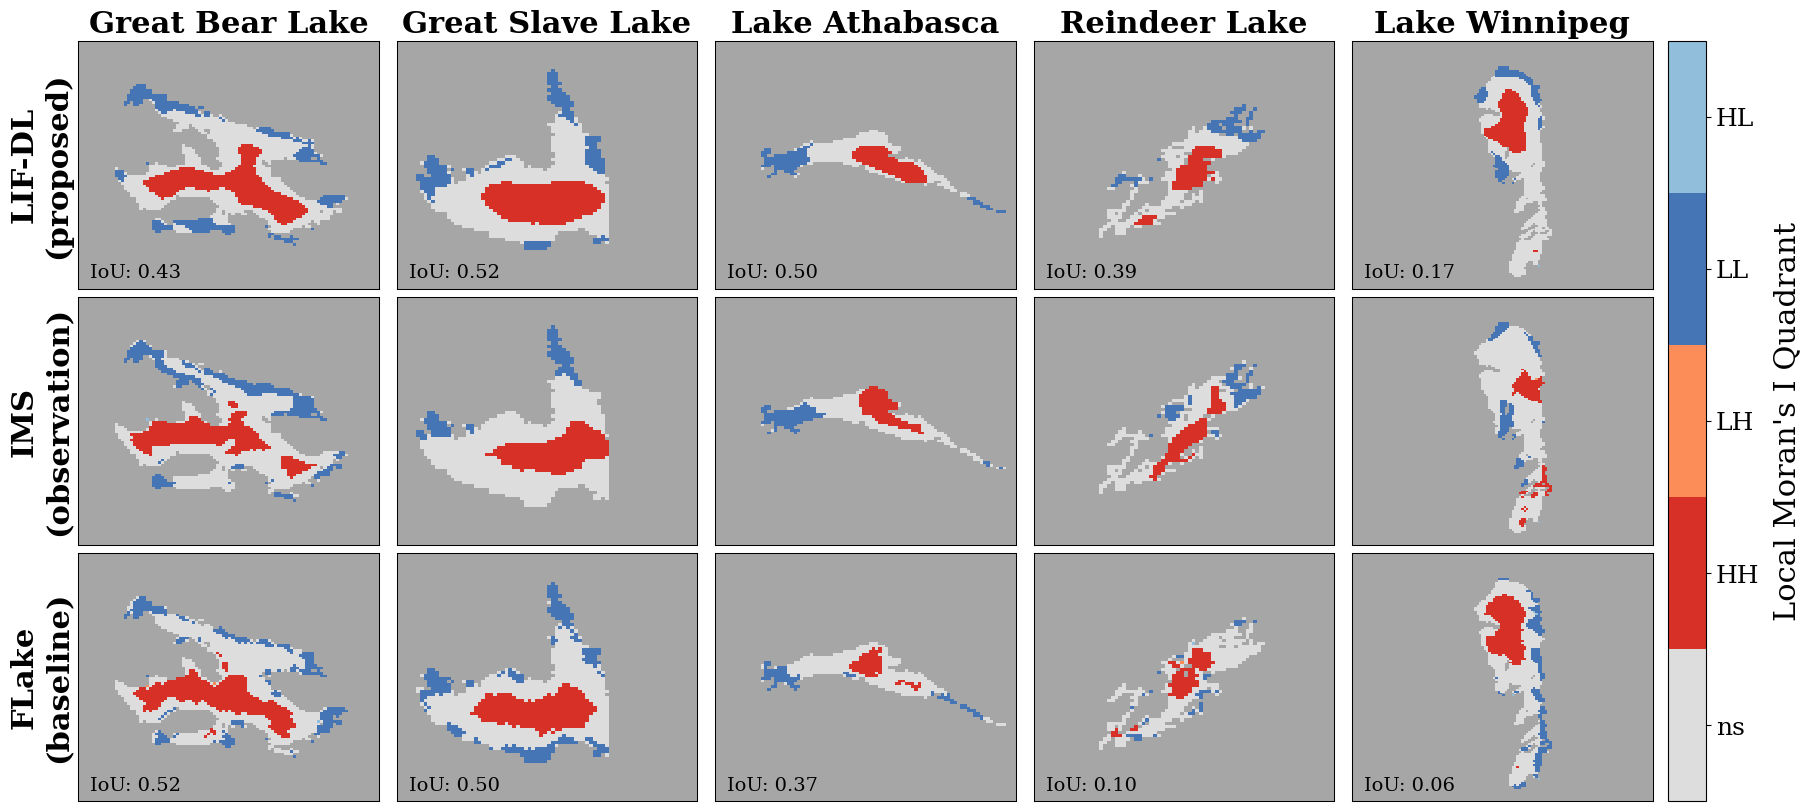

In [27]:
# Create Freeze-up Start (FUS) Local Moran's I cluster map
fig_fus_lmi = plot_local_morans_i(spatial_data, season='FUS', spatial_df=spatial_df, lake_order=lake_order, save_path=fig_dir/"FUS_lmi.png")
plt.show()

## 3.4 Temporal Evolution of Lake Ice Fraction

In [3]:
# Load FIC timeseries data from intermediate files
fic_dir = eval_dir / "intermediate" / "fic_timeseries"

# Load all FIC timeseries for each lake and source
fic_data = {}
fic_sources = ["ims", "cis", "lif_dl", "flake"]

for lake in lake_order:
    lake_key = lake.lower().replace(' ', '_')
    fic_data[lake] = {}
    
    for source in fic_sources:
        file_path = fic_dir / f"{lake_key}_{source}.csv"
        if file_path.exists():
            df = pd.read_csv(file_path, parse_dates=['Date'])
            fic_data[lake][source] = df
            print(f"Loaded: {file_path.name}")
        else:
            print(f"Missing: {file_path.name}")

print(f"\nLoaded FIC data for {len(fic_data)} lakes")
print(f"Sources available: {fic_sources}")

Loaded: great_bear_lake_ims.csv
Loaded: great_bear_lake_cis.csv
Loaded: great_bear_lake_lif_dl.csv
Loaded: great_bear_lake_flake.csv
Loaded: great_slave_lake_ims.csv
Loaded: great_slave_lake_cis.csv
Loaded: great_slave_lake_lif_dl.csv
Loaded: great_slave_lake_flake.csv
Loaded: lake_athabasca_ims.csv
Loaded: lake_athabasca_cis.csv
Loaded: lake_athabasca_lif_dl.csv
Loaded: lake_athabasca_flake.csv
Loaded: reindeer_lake_ims.csv
Loaded: reindeer_lake_cis.csv
Loaded: reindeer_lake_lif_dl.csv
Loaded: reindeer_lake_flake.csv
Loaded: lake_winnipeg_ims.csv
Loaded: lake_winnipeg_cis.csv
Loaded: lake_winnipeg_lif_dl.csv
Loaded: lake_winnipeg_flake.csv

Loaded FIC data for 5 lakes
Sources available: ['ims', 'cis', 'lif_dl', 'flake']


In [50]:
import importlib
import src.utils.plotting
importlib.reload(src.utils.plotting)
from src.utils.plotting import plot_fic_temporal_evolution

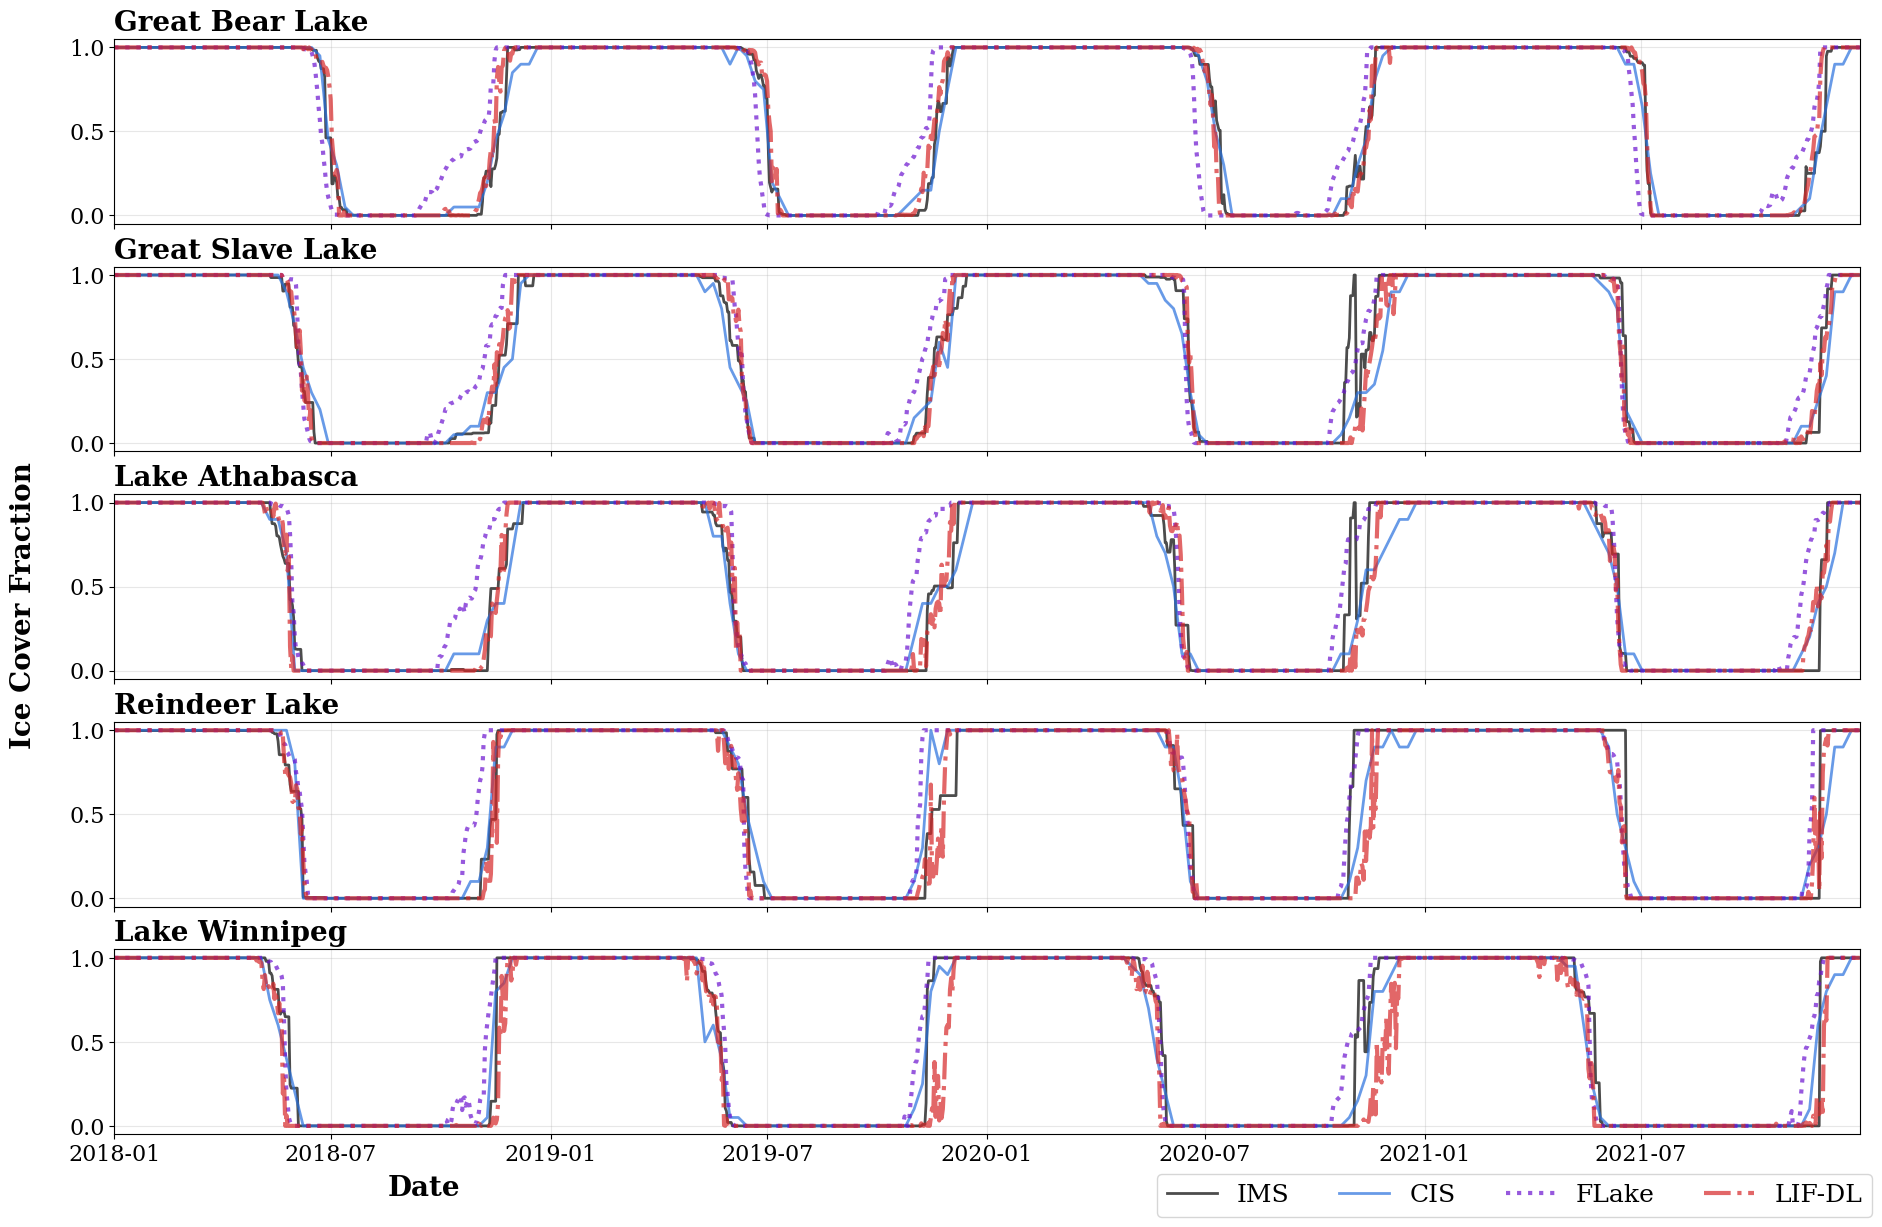

In [51]:
# Create FIC temporal evolution plot
fig_fic = plot_fic_temporal_evolution(fic_data, lake_order, save_path=fig_dir/"fic_trend.png")
plt.show()

In [ ]:
## Display the results table for the fraction of ice cover (FIC) evaluation
fic_df = pd.read_csv(eval_dir / "fic.csv")
# Drop n_samples column if exists
if 'n_samples' in fic_df.columns:
    fic_df = fic_df.drop(columns=['n_samples'])

# Compute the Average across lakes, grouped by Obs and Model
cols_for_agg = [col for col in fic_df.columns if col not in ['Lake']]
avg_fic_df = fic_df[cols_for_agg].groupby(['Obs', 'Model'], as_index=False).mean()
avg_fic_df['Lake'] = 'Average'

# Reorder columns to match original
rest_cols = [col for col in fic_df.columns if col not in ['Lake']]
avg_fic_df = avg_fic_df[['Lake'] + rest_cols]

# Append the Average row to the original fic_df
fic_df = pd.concat([fic_df, avg_fic_df], ignore_index=True)

print("Fraction of Ice Cover (FIC) Evaluation Metrics")
print("="*100)

# Create the display table with multi-index
fic_df['Lake'] = fic_df['Lake'].str.replace('_', ' ').str.title().str.replace(' ', '_')
fic_df['Model'] = fic_df['Model'].str.upper().replace('LIF-DL', 'LIF_DL').replace('FLAKE', 'FLake')
fic_df['Lake'] = pd.Categorical(fic_df['Lake'], categories=lake_order + ['Average'], ordered=True)
fic_df['Obs'] = pd.Categorical(fic_df['Obs'], categories=obs_order, ordered=True)
fic_df['Model'] = pd.Categorical(fic_df['Model'], categories=model_order, ordered=True)
fic_df = fic_df.sort_values(['Lake', 'Obs', 'Model'])
display_fic_table = fic_df.set_index(['Lake', 'Obs', 'Model'])

# Set pandas float display precision to 2 decimals
pd.options.display.float_format = '{:.2f}'.format

display_fic_table

Fraction of Ice Cover (FIC) Evaluation Metrics


MAE  RMSE  MASE
Lake             Obs Model                  
Great_Bear_Lake  IMS LIF_DL 0.02  0.06  0.41
                     FLake  0.07  0.18  1.70
Great_Slave_Lake IMS LIF_DL 0.03  0.09  0.51
                     FLake  0.05  0.12  0.96
Lake_Athabasca   IMS LIF_DL 0.03  0.10  0.54
                     FLake  0.06  0.17  1.19
Reindeer_Lake    IMS LIF_DL 0.03  0.12  0.47
                     FLake  0.04  0.15  0.61
Lake_Winnipeg    IMS LIF_DL 0.04  0.16  1.04
                     FLake  0.04  0.12  0.91
Average          IMS LIF_DL 0.03  0.10  0.59
                     FLake  0.05  0.15  1.07

: 

## 3.5 Temporal Accuracy of Ice Phenology Events

In [ ]:
# Load phenology evaluation CSV
phenology_df = pd.read_csv(eval_dir / "phenology.csv")

# Compute "Overall" results (average across lakes) per Obs and Model without attempting to average the Lake column
# Keep only the Obs/Model and numeric columns for aggregation
cols_for_agg = [c for c in phenology_df.columns if c not in ['Lake']]
overall_phenology = phenology_df[cols_for_agg].groupby(['Obs', 'Model'], as_index=False).mean()
overall_phenology['Lake'] = 'Average'

# Reorder columns to match original: Lake, Obs, Model, then the rest
rest_cols = [c for c in phenology_df.columns if c not in ['Lake', 'Obs', 'Model']]
overall_phenology = overall_phenology[['Lake', 'Obs', 'Model'] + rest_cols]

# Append the overall rows to the phenology dataframe
phenology_df = pd.concat([phenology_df, overall_phenology], ignore_index=True)

print(f"Loaded phenology evaluation from: {eval_dir / 'phenology.csv'}")
print(f"Shape: {phenology_df.shape}")
print()

# Similar to the overall display table, create a phenology display table
phenology_df['Lake'] = phenology_df['Lake'].str.replace('_', ' ').str.title().str.replace(' ', '_')
phenology_df['Model'] = phenology_df['Model'].str.upper().replace('LIF-DL', 'LIF_DL').replace('FLAKE', 'FLake')

# Sort based on the pre-defined order
phenology_df['Lake'] = pd.Categorical(phenology_df['Lake'], categories=lake_order+["Average"], ordered=True)
phenology_df['Obs'] = pd.Categorical(phenology_df['Obs'], categories=obs_order, ordered=True)
phenology_df['Model'] = pd.Categorical(phenology_df['Model'], categories=model_order, ordered=True)

# Sort by Lake, Obs, Model
phenology_df = phenology_df.sort_values(['Lake', 'Obs', 'Model'])

# Set multi-index
display_table = phenology_df.set_index(['Lake', 'Obs', 'Model'])

# Display the full table
print("Full Forecast Evaluation - phenology Metrics")
print("="*120)


# Set pandas float display precision to 2 decimals
pd.options.display.float_format = '{:.0f}'.format

display_table

: 